## Gas Turbine Fault Prediction

In [ ]:
from sklearn.svm import SVC 
from imblearn.over_sampling import SMOTE
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay


In [3]:
df = pd.read_csv("turbine_fault.csv")
df.head()

,Temperature (°C),RPM,Torque (Nm),Vibrations (mm/s),Power Output (MW),Fuel Flow Rate (kg/s),Air Pressure (kPa),Exhaust Gas Temperature (°C),Oil Temperature (°C),Fault
0,924.835708,15650.87064,3464.645167,1.675087,96.347590,2.265294,146.245460,517.611726,90.530958,0
1,893.086785,15780.75560,3190.276340,2.042084,83.288302,2.755950,166.812134,500.196460,136.047350,0
2,932.384427,15016.00207,3401.769251,2.006414,120.358735,2.574244,133.494161,516.272719,124.910039,0
3,976.151493,14623.29106,3443.024901,2.239914,104.689781,2.497101,140.141635,475.731083,123.298231,1
4,888.292331,15229.98607,3448.764050,1.865677,95.080431,2.763689,109.795667,546.737163,119.382239,1


In [4]:
df.isnull().sum()

Temperature (°C)                0
RPM                             0
Torque (Nm)                     0
Vibrations (mm/s)               0
Power Output (MW)               0
Fuel Flow Rate (kg/s)           0
Air Pressure (kPa)              0
Exhaust Gas Temperature (°C)    0
Oil Temperature (°C)            0
Fault                           0
dtype: int64

In [5]:
df.describe()

,Temperature (°C),RPM,Torque (Nm),Vibrations (mm/s),Power Output (MW),Fuel Flow Rate (kg/s),Air Pressure (kPa),Exhaust Gas Temperature (°C),Oil Temperature (°C),Fault
count,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000
mean,901.623932,15022.591497,3494.764285,1.978964,99.497230,2.505591,150.320568,498.865296,120.061923,0.306638
std,49.381498,490.048647,203.828153,0.494025,10.309697,0.316582,19.430192,28.793950,10.005188,0.461264
min,737.936633,13490.243920,2901.772806,0.411648,71.004861,1.349003,93.961769,382.327992,86.244209,0.000000
25%,868.117412,14688.039313,3355.445978,1.658465,92.387182,2.296762,137.688214,479.238499,113.652494,0.000000
50%,901.964879,15016.737355,3490.639925,1.989549,99.378143,2.500537,150.464896,498.865627,119.968056,0.000000
75%,932.692748,15346.057958,3627.482077,2.322288,106.454488,2.724751,163.130104,518.337798,126.570199,1.000000
max,1092.636575,16596.553780,4285.247541,3.556455,135.290552,3.513215,213.155426,587.423277,153.777682,1.000000


In [6]:
corr = df.corr(numeric_only = True)
corr_target = corr["Fault"].sort_values(ascending=False)

In [7]:
print(corr_target)

Fault                           1.000000
Exhaust Gas Temperature (°C)    0.044570
Air Pressure (kPa)              0.019300
Torque (Nm)                    -0.002820
Oil Temperature (°C)           -0.003800
Power Output (MW)              -0.013284
Fuel Flow Rate (kg/s)          -0.016047
RPM                            -0.018466
Vibrations (mm/s)              -0.019193
Temperature (°C)               -0.068022
Name: Fault, dtype: float64


In [8]:
import seaborn as sns

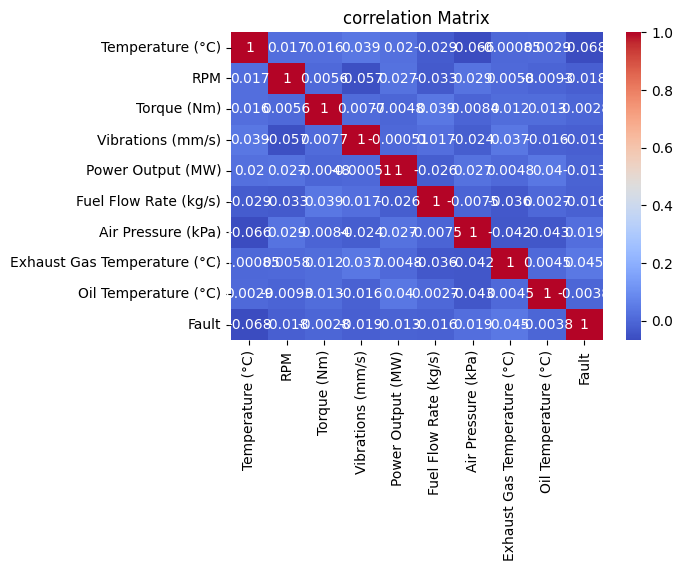

In [9]:
plt.figure(figsize=(6,4))
sns.heatmap(corr,annot = True,cmap = "coolwarm")
plt.title("correlation Matrix")
plt.show()

In [10]:
x = df.drop("Fault",axis=1)
y = df["Fault"]

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,
random_state = 42,stratify = y)

In [12]:
model1 = SVC(kernel = "rbf",C=1.0)
model1.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [14]:
prediction = model1.predict(x_test)

In [17]:
print(accuracy_score(y_test,prediction))

0.6942446043165468


In [18]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10
)

In [19]:
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [20]:
y_pred = model.predict(x_test)
# model.predict_proba(x_test)

In [21]:
print(accuracy_score(y_test,y_pred)) 

0.6870503597122302


In [22]:
print(classification_report(y_test,y_pred,zero_division=0))

              precision    recall  f1-score   support

           0       0.69      0.99      0.81       193
           1       0.00      0.00      0.00        85

    accuracy                           0.69       278
   macro avg       0.35      0.49      0.41       278
weighted avg       0.48      0.69      0.57       278



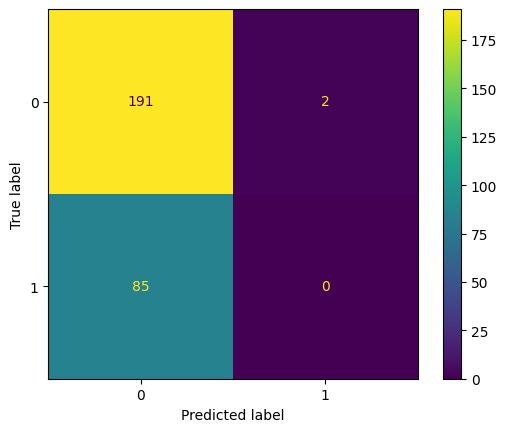

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
##ConfusionMatrixDisplay.from_estimator(model,x_test,y_test)

In [24]:
importance = model.feature_importances_

In [25]:
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance":importance
}).sort_values(by = "Importance",ascending=False)

In [26]:
print(feature_importance)

                        Feature  Importance
0              Temperature (°C)    0.127508
2                   Torque (Nm)    0.117950
5         Fuel Flow Rate (kg/s)    0.113568
6            Air Pressure (kPa)    0.112584
1                           RPM    0.108517
7  Exhaust Gas Temperature (°C)    0.106901
8          Oil Temperature (°C)    0.104671
4             Power Output (MW)    0.104183
3             Vibrations (mm/s)    0.104117


<Figure size 600x400 with 0 Axes>

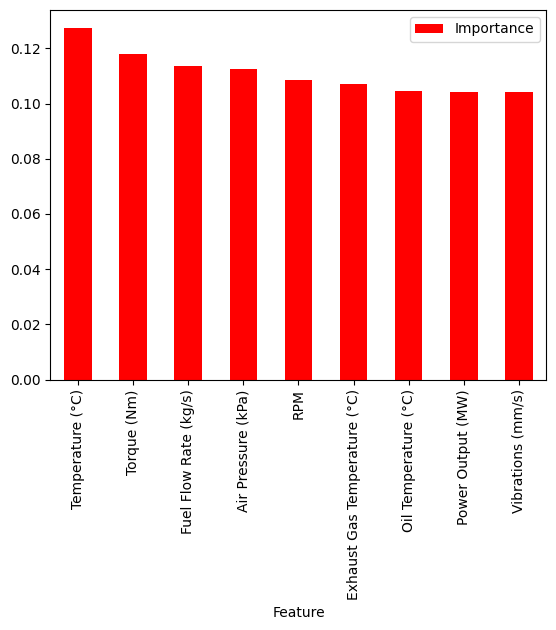

In [27]:
plt.figure(figsize=(6,4))
feature_importance.plot(kind="bar",x="Feature",y="Importance",color="red")
plt.show()

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,15]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

In [29]:
grid.best_params_

{'max_depth': 5, 'n_estimators': 300}